# Brian2 install check — single LIF neuron

First Brian2 test in this project (cold start on the spiking side, per the roadmap after the
two-layer/episodic memory work). Nothing architectural here — just confirming the install
works end to end: build a standard leaky integrate-and-fire neuron, drive it with constant
input current, confirm it integrates, spikes, and resets correctly, and that monitors/plots
work. `brian2==2.9.0` installed via conda-forge into the `developing-mind` env.

In [1]:
import brian2
from brian2 import *
import matplotlib.pyplot as plt

%matplotlib inline
prefs.codegen.target = 'numpy'  # avoid needing a C++ compiler on Windows for this quick check
print("Brian2 version:", brian2.__version__)

Brian2 version: 2.9.0


## Single LIF neuron, constant drive

Standard leaky integrate-and-fire: `tau * dv/dt = -(v - v_rest) + R*I`, threshold at
`v_thresh`, reset to `v_reset`, refractory period `t_ref`. Units handled natively by Brian2's
quantity system (`mV`, `ms`, etc.) rather than hand-tracked scale factors.

In [2]:
start_scope()

tau = 10*ms
v_rest = -70*mV
v_thresh = -50*mV
v_reset = -65*mV
t_ref = 5*ms
R = 100*Mohm
I = 0.25*nA  # constant drive, chosen to comfortably clear threshold

eqs = '''
dv/dt = (v_rest - v + R*I) / tau : volt (unless refractory)
'''

neuron = NeuronGroup(1, eqs, threshold='v > v_thresh', reset='v = v_reset',
                      refractory=t_ref, method='exact')
neuron.v = v_rest

state_mon = StateMonitor(neuron, 'v', record=True)
spike_mon = SpikeMonitor(neuron)

run(200*ms)

print(f"Spike count over 200ms: {spike_mon.count[0]}")
print(f"Spike times (ms): {[round(t/ms, 2) for t in spike_mon.t]}")

Spike count over 200ms: 10
Spike times (ms): [16.0, 34.8, 53.6, 72.4, 91.2, 110.0, 128.8, 147.6, 166.4, 185.2]


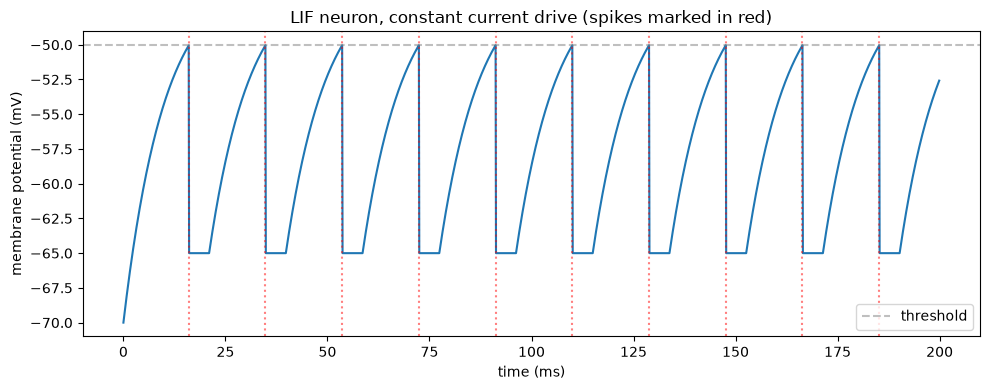

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(state_mon.t/ms, state_mon.v[0]/mV)
for t in spike_mon.t:
    plt.axvline(x=t/ms, color='red', linestyle=':', alpha=0.5)
plt.axhline(y=v_thresh/mV, color='gray', linestyle='--', alpha=0.5, label='threshold')
plt.xlabel('time (ms)')
plt.ylabel('membrane potential (mV)')
plt.title('LIF neuron, constant current drive (spikes marked in red)')
plt.legend()
plt.tight_layout()
plt.savefig('lif_single_neuron.png', dpi=100)
plt.show()

## Sanity check: firing rate scales with input current

Quick f-I curve over a few current levels — should be monotonically increasing (more drive,
faster to threshold, higher rate), and zero below rheobase. Confirms the dynamics respond
sensibly to parameter changes, not just that one hardcoded run happens to spike.

I=100. pA: 0 spikes in 500ms -> 0.0 Hz


I=150. pA: 0 spikes in 500ms -> 0.0 Hz


I=200. pA: 0 spikes in 500ms -> 0.0 Hz


I=250. pA: 26 spikes in 500ms -> 52.0 Hz


I=300. pA: 35 spikes in 500ms -> 70.0 Hz


I=0.4 nA: 47 spikes in 500ms -> 94.0 Hz


I=0.5 nA: 55 spikes in 500ms -> 110.0 Hz


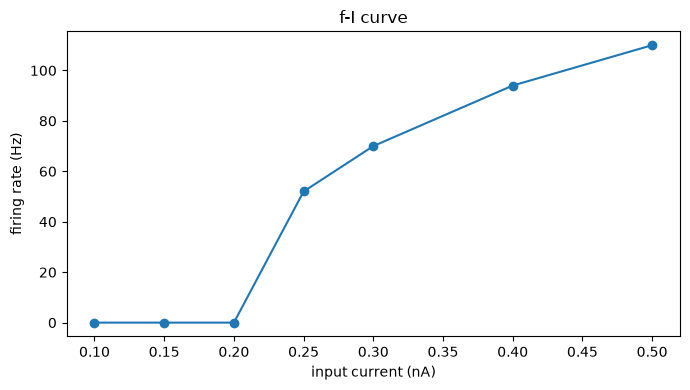


Monotonically non-decreasing: True


In [4]:
currents = [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5] * nA
rates = []

for I_val in currents:
    start_scope()
    eqs_fi = '''
    dv/dt = (v_rest - v + R*I_val) / tau : volt (unless refractory)
    '''
    neuron_fi = NeuronGroup(1, eqs_fi, threshold='v > v_thresh', reset='v = v_reset',
                             refractory=t_ref, method='exact')
    neuron_fi.v = v_rest
    spike_mon_fi = SpikeMonitor(neuron_fi)
    run(500*ms)
    rate_hz = spike_mon_fi.count[0] / (500*ms) / Hz
    rates.append(rate_hz)
    print(f"I={I_val}: {spike_mon_fi.count[0]} spikes in 500ms -> {rate_hz:.1f} Hz")

plt.figure(figsize=(7, 4))
plt.plot(currents/nA, rates, 'o-')
plt.xlabel('input current (nA)')
plt.ylabel('firing rate (Hz)')
plt.title('f-I curve')
plt.tight_layout()
plt.savefig('lif_fi_curve.png', dpi=100)
plt.show()

monotonic = all(rates[i] <= rates[i+1] for i in range(len(rates)-1))
print(f"\nMonotonically non-decreasing: {monotonic}")

## Result

If both cells above ran without error and produced a spiking trace + a sensible f-I curve,
the Brian2 install is confirmed working end to end (equations, units, threshold/reset,
refractory period, monitors, and plotting all functioning) — safe to build on for real STDP
work next.

## Compiled backend check (`cython` target) — the one that actually matters for real work

The runs above used `codegen.target = 'numpy'` deliberately, to isolate the install check from
the C++ compiler path. That target is fine for tiny toy networks but far too slow for real
STDP/SNN work — worth checking the compiled backend actually works *before* relying on it.

The conda install pulled in `m2w64-gcc-libs`/`gsl` as dependencies, but that MinGW package
turns out to be **runtime DLLs only** (`libstdc++`, `libgomp`, etc.) — no actual `g++`/`gcc`
binary. It's not a usable C++ compiler on its own. What actually compiles Brian2's generated
code is Python's standard Windows toolchain: **MSVC**, auto-detected via `vswhere` from the
VS Build Tools install already on this machine (`cl.exe` found under
`...\Microsoft Visual Studio\18\BuildTools\VC\Tools\MSVC\...`), not on `PATH` directly
but discovered automatically by `distutils`/`setuptools` the way it always does on Windows.
No manual toolchain setup needed — confirming that directly rather than assuming it from the
dependency list.

In [5]:
prefs.codegen.target = 'cython'

start_scope()
eqs_c = 'dv/dt = -v/(10*ms) : 1'
Gc = NeuronGroup(1, eqs_c, threshold='v>1', reset='v=0', method='exact')
Gc.v = 0.5
mon_c = StateMonitor(Gc, 'v', record=True)
run(5*ms)
print("Compiled (cython/MSVC) target: neuron ran, final v =", mon_c.v[0][-1])

Compiled (cython/MSVC) target: neuron ran, final v = 0.3063131970922089


### Closer to real usage: neurons + synapses with a weight variable

Plain single-neuron dynamics compiling is necessary but not sufficient — STDP work needs
`Synapses` with weight variables and `on_pre`/`on_post` effects to compile too.

In [6]:
start_scope()
prefs.codegen.target = 'cython'

eqs_s = 'dv/dt = -v/(10*ms) : 1'
Gs = NeuronGroup(2, eqs_s, threshold='v>1', reset='v=0', method='exact')
Gs.v = [0, 0]

P = SpikeGeneratorGroup(1, [0, 0, 0], [1, 2, 3]*ms)
S_drive = Synapses(P, Gs, on_pre='v_post += 1.1')
S_drive.connect(i=0, j=0)

S = Synapses(Gs, Gs, 'w : 1', on_pre='v_post += w')
S.connect(i=0, j=1)
S.w = 0.5

mon_s = SpikeMonitor(Gs)
run(10*ms)
print("Compiled target: NeuronGroup + SpikeGeneratorGroup + weighted Synapses all compiled and ran")
print("spike counts:", dict(zip(range(2), mon_s.count)))

Compiled target: NeuronGroup + SpikeGeneratorGroup + weighted Synapses all compiled and ran
spike counts: {0: np.int32(3), 1: np.int32(1)}


## Result

Compiled (`cython`, MSVC-backed) codegen target works end to end — single neurons, spike
generators, and weighted synapses with `on_pre` effects all compile and run correctly. Safe
to default to `prefs.codegen.target = 'cython'` for real STDP work going forward instead of
`'numpy'` (much faster for anything beyond toy-scale networks). No manual compiler
installation needed — MSVC Build Tools were already present and get auto-detected.